<a href="https://colab.research.google.com/github/vtopols/Practice/blob/main/mobile_phone_price_forecast_sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as nn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("kaggle/Mobile_phone_price.csv.csv")

In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegression, HuberRegressor, RANSACRegressor, TheilSenRegressor, LinearRegression

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Brand                   407 non-null    object
 1   Model                   407 non-null    object
 2   Storage                 407 non-null    object
 3   RAM                     407 non-null    object
 4   Screen Size (inches)    407 non-null    object
 5   Camera (MP)             407 non-null    object
 6   Battery Capacity (mAh)  407 non-null    int64 
 7   Price ($)               407 non-null    object
dtypes: int64(1), object(7)
memory usage: 25.6+ KB


In [ ]:
import re
def sum_numbers_in_string(s):
  parts = s.split('+')
  total_sum = 0
  for part in parts:
    cleaned_part = part.strip().strip('(MP)')
    if cleaned_part.isdecimal():
      total_sum +=float(cleaned_part)

  return total_sum

def sum_numbers(s):
  parts = re.findall(r'\d+\.\d+', s)
  total_sum = 0
  for part in parts:
    cleaned_part = part.strip().strip('()')
    if re.match(r'^\d+\.\d+$', cleaned_part):
      total_sum += float(cleaned_part)

  return total_sum

In [ ]:
df = pd.read_csv("kaggle/Mobile_phone_price.csv.csv")
df['Screen Size (inches)'] = df['Screen Size (inches)'].apply(sum_numbers)
df['Price ($)'] = df['Price ($)'].str.replace(r'\D+', '', regex=True).astype(int)
df['RAM '] = df['RAM '].str.replace(r'\D+', '', regex=True).astype(int)
df['Storage '] = df['Storage '].str.replace(r'\D+', '', regex=True).astype(int)
df['Camera (MP)'] = df['Camera (MP)'].apply(sum_numbers_in_string)
df.drop(columns=['Model'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407 entries, 0 to 406
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Brand                   407 non-null    object 
 1   Storage                 407 non-null    int64  
 2   RAM                     407 non-null    int64  
 3   Screen Size (inches)    407 non-null    float64
 4   Camera (MP)             407 non-null    float64
 5   Battery Capacity (mAh)  407 non-null    int64  
 6   Price ($)               407 non-null    int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 22.4+ KB


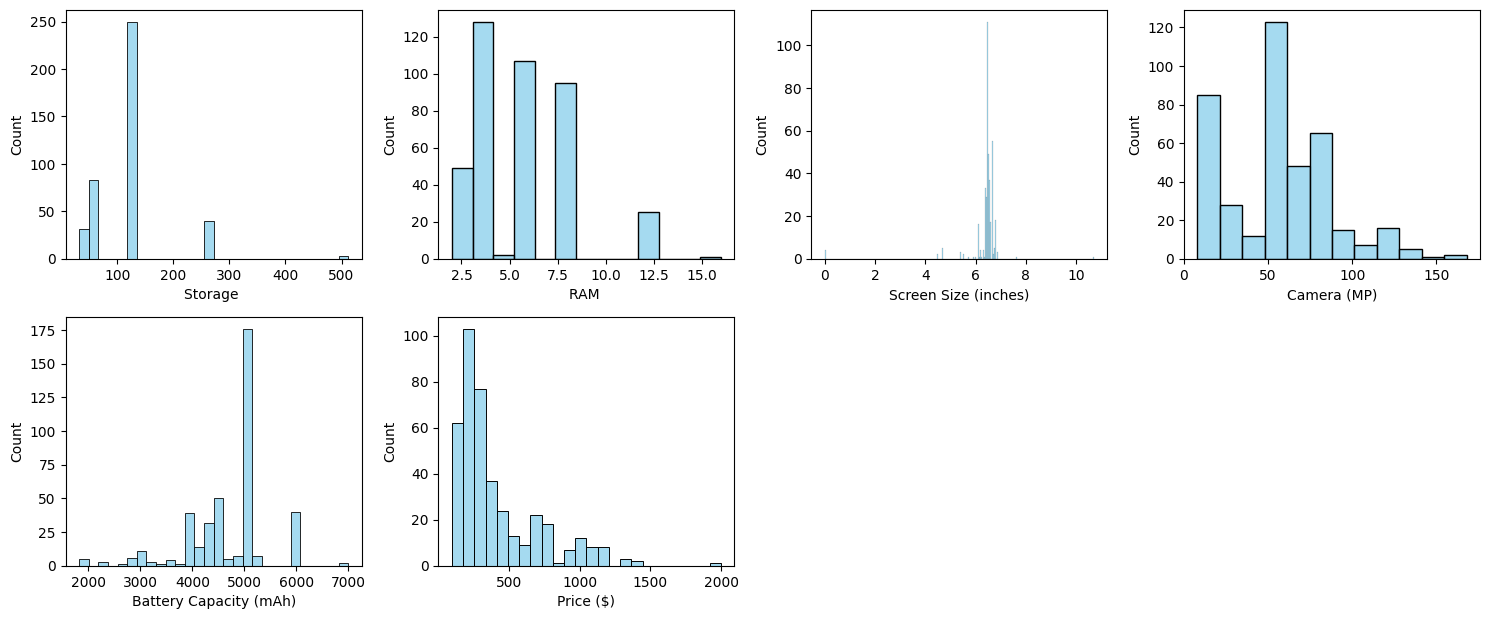

In [ ]:
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns
categorical_features = df.select_dtypes(include=['object']).columns
plt.figure(figsize=(15, 12))
for i, col in enumerate(numeric_features, 1):
  plt.subplot(4, 4, i)
  sns.histplot(df[col], kde=False, color='skyblue')
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop("Price ($)", axis=1)
y = df["Price ($)"]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

In [ ]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ("num", StandardScaler(), ['Storage ', 'RAM ', 'Screen Size (inches)', 'Camera (MP)', 'Battery Capacity (mAh)'])
    ],
    verbose_feature_names_out=False)
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVC
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LogisticRegression, HuberRegressor, RANSACRegressor, TheilSenRegressor, LinearRegression


In [ ]:
def eval (grid, X_test, y_test, model_name):
  best_model = grid.best_estimator_
  y_pred = best_model.predict(X_test)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  return{
      "model": model_name,
      "best_params": grid.best_params_,
      "MSE": mse,
      "R^2": r2
  }
result_metrics = []

In [ ]:
param_grid = {'poly__degree': [1, 2, 3]}
pipeline = Pipeline([('poly', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())])
grid = GridSearchCV(pipeline, param_grid, scoring='neg_mean_squared_error', cv=5)
grid.fit(X_train, y_train)
res = eval(grid, X_test, y_test, "Линейная регрессия")
result_metrics.append(res)

In [ ]:
param_grid = {'poly__degree': [1, 2, 3], "model__epsilon": [1.5, 2.0, 2.5, 3.0], "model__alpha":[0.01, 0.1, 1.0]}
pipeline = Pipeline([('poly', PolynomialFeatures(include_bias=False)), ('model', HuberRegressor(max_iter=2000))])
grid = GridSearchCV(pipeline, param_grid, scoring='neg_mean_squared_error', cv=5)
grid.fit(X_train, y_train)
res = eval(grid, X_test, y_test, "HuberRegressor")
result_metrics.append(res)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_

In [ ]:
param_grid = {'poly__degree': [1, 2, 3], "model__alpha": [1.0, 10.0, 15, 20, 25]}
pipeline = Pipeline([('poly', PolynomialFeatures(include_bias=False)), ('model', Ridge())])
grid = GridSearchCV(pipeline, param_grid, scoring='neg_mean_squared_error', cv=5)
grid.fit(X_train, y_train)
res = eval(grid, X_test, y_test, "Ridge")
result_metrics.append(res)

In [ ]:
param_grid = {'poly__degree': [1, 2, 3], "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0]}
pipeline = Pipeline([('poly', PolynomialFeatures(include_bias=False)), ('model', Lasso(max_iter = 2000))])
grid = GridSearchCV(pipeline, param_grid, scoring='neg_mean_squared_error', cv=5)
grid.fit(X_train, y_train)
res = eval(grid, X_test, y_test, "Lasso")
result_metrics.append(res)

In [ ]:
param_grid = {'poly__degree': [1, 2, 3], "model__alpha":[0.001, 0.01, 0.1, 1.0], "model__l1_ratio": [0.05, 0.1, 0.2, 0.5, 0.8]}
pipeline = Pipeline([('poly', PolynomialFeatures(include_bias=False)), ('model', ElasticNet(max_iter=2000))])
grid = GridSearchCV(pipeline, param_grid, scoring='neg_mean_squared_error', cv=5)
grid.fit(X_train, y_train)
res = eval(grid, X_test, y_test, "Elastic")
result_metrics.append(res)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.193e+05, tolerance: 2.122e+03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.236e+05, tolerance: 2.203e+03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.408e+05, tolerance: 2.207e

In [ ]:
param_grid = {'poly__degree': [1, 2, 3], "model__n_neighbors": [15, 17, 19, 21, 23, 25, 30], "model__weights":["uniform", "distance"]}
pipeline = Pipeline([('poly', PolynomialFeatures(include_bias=False)), ('model', KNeighborsRegressor())])
grid = GridSearchCV(pipeline, param_grid, scoring='neg_mean_squared_error', cv=5)
grid.fit(X_train, y_train)
res = eval(grid, X_test, y_test, "KNN")
result_metrics.append(res)

In [ ]:
param_grid = {'poly__degree': [1, 2, 3], "model__C": [0.1, 1, 10, 100], "model__kernel":['rbf', 'linear'], "model__gamma": ['scale', 'auto', 0.1, 1]}
pipeline = Pipeline([('poly', PolynomialFeatures(include_bias=False)), ('model', SVC())])
grid = GridSearchCV(pipeline, param_grid, scoring='neg_mean_squared_error', cv=5)
grid.fit(X_train, y_train)
res = eval(grid, X_test, y_test, "SVC")
result_metrics.append(res)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [ ]:
param_grid = {'poly__degree': [1, 2, 3], "model__C": [0.01, 0.1, 1, 10]}
pipeline = Pipeline([('poly', PolynomialFeatures(include_bias=False)), ('model', LogisticRegression(max_iter=2000))])
grid = GridSearchCV(pipeline, param_grid, scoring='neg_mean_squared_error', cv=5)
grid.fit(X_train, y_train)
res = eval(grid, X_test, y_test, "Логистическая")
result_metrics.append(res)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [ ]:
param_grid = {'poly__degree': [1, 2, 3], "model__max_trials": [100, 200, 500], "model__residual_threshold": [1.0, 2.0, 5.0], "model__min_samples": [0.5, 0.7, 0.9]}
pipeline = Pipeline([('poly', PolynomialFeatures(include_bias=False)), ('model', RANSACRegressor())])
grid = GridSearchCV(pipeline, param_grid, scoring='neg_mean_squared_error', cv=5)
grid.fit(X_train, y_train)
res = eval(grid, X_test, y_test, "RANSAC")
result_metrics.append(res)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


KeyboardInterrupt: 

In [ ]:
param_grid = {'poly__degree': [1, 2, 3], 'model__max_iter': [300, 500, 1000], 'model__fit_intercept': [True, False]}
pipeline = Pipeline([('poly', PolynomialFeatures(include_bias=False)), ('model', TheilSenRegressor())])
grid = GridSearchCV(pipeline, param_grid, scoring='neg_mean_squared_error', cv=5)
grid.fit(X_train, y_train)
res = eval(grid, X_test, y_test, "TheilSen")
result_metrics.append(res)

In [ ]:
results_df = pd.DataFrame(result_metrics)
results_df_sorted = results_df.sort_values(by="MSE", ascending=True)
results_df_sorted

,model,best_params,MSE,R^2
1,HuberRegressor,"{'model__alpha': 0.01, 'model__epsilon': 3.0, ...",16922.811806,0.806570
0,Линейная регрессия,{'poly__degree': 1},17074.536384,0.804836
